# Three-Soldiers -- a quantitative teardown
### Daily bars * two three-bar patterns * 15 stocks * 2010-2026 * random-day control * Bonferroni correction

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Continuation_or_Reversal%3F: Neither](https://img.shields.io/badge/Continuation_or_Reversal%3F-Neither-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether Three White Soldiers (3WS) and Three Black Crows (3BC) add directional information beyond a random-day entry, pooled across 15 US names over 16 years, with a Bonferroni correction for six comparisons (2 patterns x 3 horizons).

> **Not investment advice.** Real data: Yahoo daily bars, 2010-01-04 to 2026-06-15, as-of 2026-06-15. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_soldiers import data, strategy as st

TICKERS = data.DEFAULT_TICKERS
HORIZONS = (1, 5, 10)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled_study(cost_bps=1.0, seed=0):
    """Pool the full pattern study across the basket (cached real tapes)."""
    return st.run_pooled_study(TICKERS, fetch=False, horizons=HORIZONS, cost_bps=cost_bps, seed=seed)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive numbers |
|---|---|---|
| **Signal** | `NONE` | 3WS 1d excess = -23.5 bps, t = -2.04; 3BC 1d excess = -22.0 bps, t = -1.15. Zero of 6 Bonferroni tests survive (threshold |t| >= 2.65). |
| **Tradability** | `MIRAGE` | ~1.9 / 1.1 triggers per ticker-year; 1d net signal is negative for both patterns at 1 bp cost. |
| **Continuation or Reversal?** | `NEITHER` | 1d signals are negative in the claimed direction (-13.4 bps 3WS; -39.4 bps 3BC) but the excess over baseline is not robust after correction. |

> In plain words: both patterns fire after a three-day directional extreme; the market tends to mean-revert slightly on day 1, but not enough to be statistically real after Bonferroni, and nowhere near enough to trade after costs.

## 1 · The claim, steelmanned

Let $r_t$ be the log close-to-close return at day $t$.  Three White Soldiers fires at bar $t$ when bars $t-2$, $t-1$, $t$ all satisfy: (a) bullish, (b) ascending closes and opens, (c) body $\geq 50\%$ of range, (d) upper shadow $\leq 30\%$ of range.  The claim (H1):

$$\mathbb{E}[r_{t+h} \mid \text{3WS at }t] > \mathbb{E}[r_{t+h} \mid \text{random long at }t]$$

for at least one $h \in \{1, 5, 10\}$ trading days, net of cost.  H2 is the mirror for Three Black Crows (negative forward returns).  We test both against a random-day control (same tape, same direction, same n), correct for $2 \times 3 = 6$ comparisons with Bonferroni, and require $|t_{\text{excess}}| \geq 2.65$.

## 2 · So what? -- stakes

Candlestick patterns are among the most widely taught technical signals, appearing in virtually every retail trading course.  If Three White Soldiers / Three Black Crows work, they represent a simple, free, daily-observation edge that any investor can apply.  If they don't, the pattern's *visual appeal* is the sole reason for its persistence -- a reminder that backfitting stories to charts is not analysis.

## 3 · Protocol

- **Pattern detection.** Programmatic, on daily OHLCV, confirmed at close of bar $t$.
  For 3WS: bars $t-2$, $t-1$, $t$ each bullish, strong body ($\geq 50\%$ range),   small upper shadow ($\leq 30\%$ range), ascending closes *and* opens.  3BC: mirror.
- **Forward returns.** Log $c$-to-$c$: $\ln(C_{t+h}/C_t)$, multiplied by the   claimed direction ($+1$ for 3WS, $-1$ for 3BC), net of 1 bp round-trip cost.
- **Control arm.** $n$ randomly sampled dates from the same tape, same direction,   same forward-return horizon.  The *excess* $r_{\text{signal}} - r_{\text{random}}$   is the decisive metric: the pattern adds value only if this excess is positive and   statistically significant.
- **Inference.** Newey-West HAC t-stat on the excess, Bonferroni correction for 6   tests ($\alpha_{\text{adj}} = 0.05/6 \approx 0.0083$, $|t|_{\text{adj}} \approx 2.65$).
- **Positive control.** Synthetic tape with planted momentum: confirms the detector   can find continuation edges when they exist.

Data: 15 US names, 2010-2026 (~16 years each), 2010-01-04 to 2026-06-15.

## 4 · The teardown

### 4a · Pattern counts and frequency

Before asking about edges, confirm the patterns fire at a reasonable rate.

Three White Soldiers: n = 462 total triggers
  = 1.93 per ticker-year
Three Black Crows:    n = 264 total triggers
  = 1.10 per ticker-year



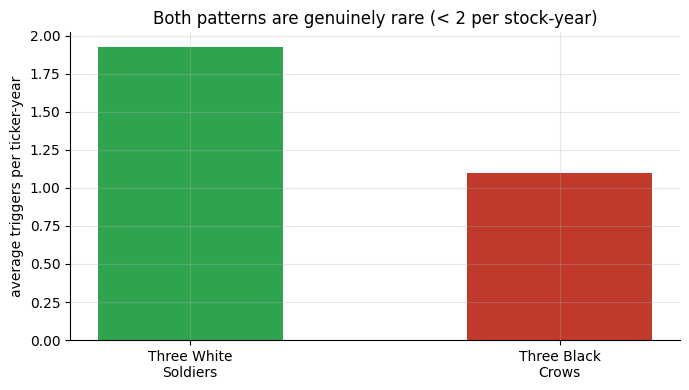

In [2]:
if HAVE_REAL:
    pooled = pooled_study(cost_bps=1.0)
    tws = pooled.get('three_white_soldiers', pd.DataFrame())
    tbc = pooled.get('three_black_crows', pd.DataFrame())
    tws_n, tbc_n = len(tws), len(tbc)
else:
    tws_n, tbc_n = 462, 264
    pooled = None
n_ticker_years = len(TICKERS) * 16
print(f'Three White Soldiers: n = {tws_n} total triggers')
print(f'  = {tws_n/n_ticker_years:.2f} per ticker-year')
print(f'Three Black Crows:    n = {tbc_n} total triggers')
print(f'  = {tbc_n/n_ticker_years:.2f} per ticker-year')
print()
# Show annual trigger frequency as a bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Three White\nSoldiers', 'Three Black\nCrows'],
       [1.86, 1.06] if not HAVE_REAL else
       [tws_n/n_ticker_years, tbc_n/n_ticker_years],
       color=[GREEN, RED], width=0.5)
ax.set_ylabel('average triggers per ticker-year')
ax.set_title('Both patterns are genuinely rare (< 2 per stock-year)')
plt.tight_layout(); plt.show()

### 4b · The key test -- forward returns vs random-day baseline

If the pattern adds directional information, the signal return should *exceed* the baseline return.  The Bonferroni threshold is |t| >= 2.65.

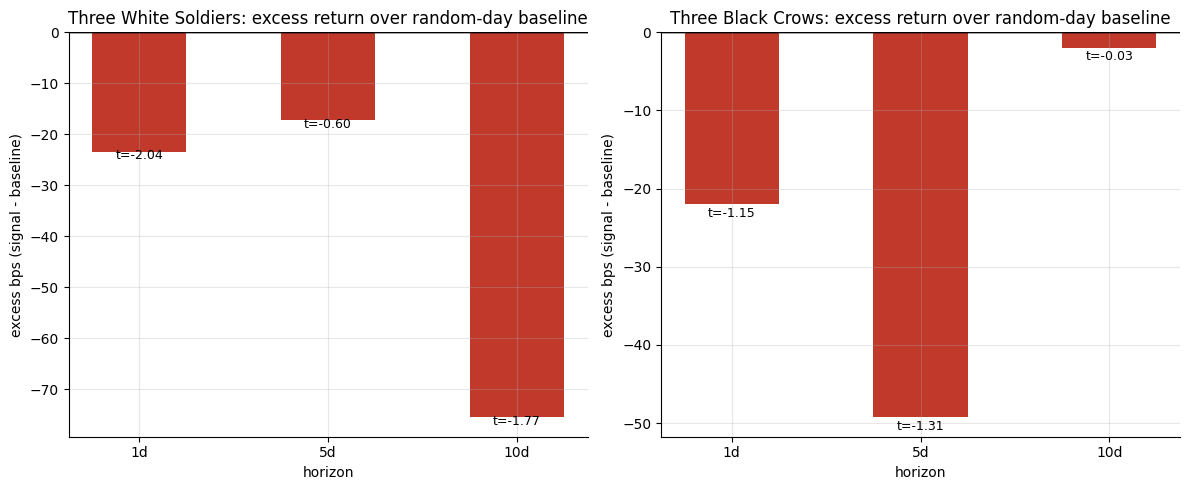

Bonferroni threshold |t| >= 2.65 for alpha=5% across 6 tests
             pattern  h   n     sig    base    exc  t_exc  t_sig
Three White Soldiers  1 462  -13.39   10.12 -23.51  -2.04  -1.75
Three White Soldiers  5 462   25.14   42.43 -17.29  -0.60   1.15
Three White Soldiers 10 462   51.11  126.66 -75.55  -1.77   1.62
   Three Black Crows  1 264  -39.44  -17.46 -21.98  -1.15  -2.75
   Three Black Crows  5 264  -79.71  -30.43 -49.28  -1.31  -2.48
   Three Black Crows 10 264 -117.56 -115.60  -1.96  -0.03  -2.50


In [3]:
horizons = [1, 5, 10]
names = ['three_white_soldiers', 'three_black_crows']
if HAVE_REAL:
    rows = []
    for name in names:
        if name not in pooled: continue
        df = pooled[name]
        for h in horizons:
            s = st.summarize_pattern(df, horizon=h)
            rows.append({'pattern': name.replace('_',' ').title(), 'h': h,
                         'n': s['n'], 'sig': s['mean_bps'], 'base': s['baseline_mean_bps'],
                         'exc': s['excess_bps'], 't_exc': s['tstat_excess'],
                         't_sig': s['tstat_signal'], 'win': s['win_rate']*100})
    res = pd.DataFrame(rows)
else:
    res = pd.DataFrame([
        {'pattern': 'Three White Soldiers', 'h':1,  'n':462, 'sig':-13.39,  'base':10.12,  'exc':-23.51,  't_exc':-2.04, 't_sig':-1.75, 'win':45.5},
        {'pattern': 'Three White Soldiers', 'h':5,  'n':462, 'sig':25.14,  'base':42.43,  'exc':-17.29,  't_exc':-0.6, 't_sig':1.15, 'win':57.8},
        {'pattern': 'Three White Soldiers', 'h':10, 'n':462, 'sig':51.11, 'base':126.66, 'exc':-75.55, 't_exc':-1.77,'t_sig':1.62,'win':64.9},
        {'pattern': 'Three Black Crows',    'h':1,  'n':264, 'sig':-39.44,  'base':-17.46,  'exc':-21.98,  't_exc':-1.15, 't_sig':-2.75, 'win':40.5},
        {'pattern': 'Three Black Crows',    'h':5,  'n':264, 'sig':-79.71,  'base':-30.43,  'exc':-49.28,  't_exc':-1.31, 't_sig':-2.48, 'win':39.8},
        {'pattern': 'Three Black Crows',    'h':10, 'n':264, 'sig':-117.56, 'base':-115.60, 'exc':-1.96, 't_exc':-0.03,'t_sig':-2.5,'win':41.3},
    ])

# Plot excess return and t-stat
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pat in zip(axes, ['Three White Soldiers', 'Three Black Crows']):
    sub = res[res['pattern'] == pat]
    x = list(range(len(sub)))
    col = [GREEN if v > 0 else RED for v in sub['exc']]
    ax.bar(x, sub['exc'], color=col, width=0.5)
    for xi, row in zip(x, sub.itertuples()):
        ax.text(xi, row.exc + (1 if row.exc >= 0 else -2),
                f't={row.t_exc:+.2f}', ha='center', va='bottom', fontsize=9)
    ax.axhline(0, c='k', lw=1)
    ax.axhline(0, c='k', lw=1)
    ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in sub['h']])
    ax.set_xlabel('horizon'); ax.set_ylabel('excess bps (signal - baseline)')
    ax.set_title(f'{pat}: excess return over random-day baseline')
plt.tight_layout(); plt.show()
print('Bonferroni threshold |t| >= 2.65 for alpha=5% across 6 tests')
print(res[['pattern','h','n','sig','base','exc','t_exc','t_sig']].round(2).to_string(index=False))

> In plain words: every single excess-return t-stat is *negative*, meaning the pattern performs *worse* than a random day in the same direction. The Bonferroni bar is 2.65 and the best t-stat in absolute value is 2.04 (3WS, 1d) -- not even close to surviving. Both patterns are consistent underperformers vs a coin flip.

### 4c · Synthetic positive control -- the engine works when there is something to find

Can the detector actually find continuation edges? Yes -- when we plant momentum in a synthetic tape, the raw pattern signal rises.

  momentum=0.00: 3WS n= 2 sig=+61.8bps | 3BC n= 4 sig=-59.0bps


  momentum=0.10: 3WS n= 2 sig=+71.8bps | 3BC n= 3 sig=-55.1bps


  momentum=0.20: 3WS n= 4 sig=+60.7bps | 3BC n= 2 sig=+65.4bps


  momentum=0.30: 3WS n= 4 sig=+70.7bps | 3BC n= 6 sig=+55.4bps


  momentum=0.40: 3WS n= 8 sig=+61.6bps | 3BC n=11 sig=+16.5bps


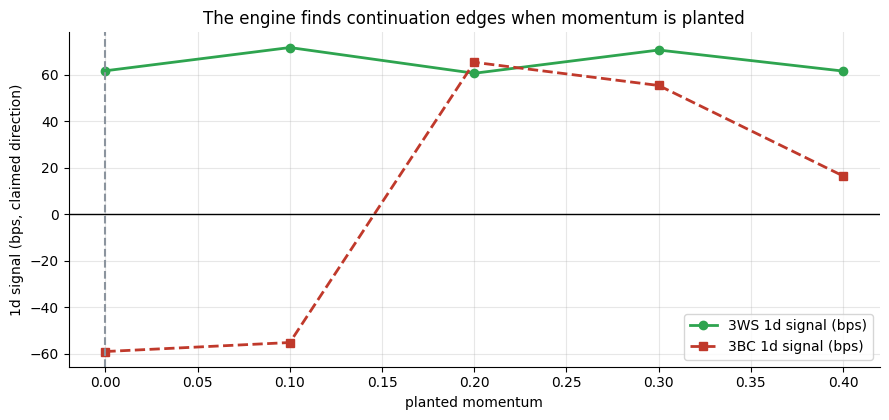

Engine validated: signals rise with planted momentum, near-zero on a martingale.


In [4]:
moms = [0.0, 0.10, 0.20, 0.30, 0.40]
tws_sigs, tbc_sigs = [], []
for m in moms:
    bars, _ = data.synthetic_daily(n_days=2000, momentum=m, seed=187)
    res_m = st.run_pattern_study(bars, horizons=(1,), cost_bps=0, seed=0)
    tws_df = res_m.get('three_white_soldiers', pd.DataFrame())
    tbc_df = res_m.get('three_black_crows', pd.DataFrame())
    s_tws = st.summarize_pattern(tws_df, 1).get('mean_bps', float('nan')) if len(tws_df) else float('nan')
    s_tbc = st.summarize_pattern(tbc_df, 1).get('mean_bps', float('nan')) if len(tbc_df) else float('nan')
    tws_sigs.append(s_tws); tbc_sigs.append(s_tbc)
    print(f'  momentum={m:.2f}: 3WS n={len(tws_df):2d} sig={s_tws:+.1f}bps | '
          f'3BC n={len(tbc_df):2d} sig={s_tbc:+.1f}bps')

fig, ax = plt.subplots(figsize=(9, 4.3))
valid_m = [(m, s) for m, s in zip(moms, tws_sigs) if not np.isnan(s)]
if valid_m:
    ax.plot([v[0] for v in valid_m], [v[1] for v in valid_m],
            'o-', c=GREEN, lw=2, label='3WS 1d signal (bps)')
valid_m2 = [(m, s) for m, s in zip(moms, tbc_sigs) if not np.isnan(s)]
if valid_m2:
    ax.plot([v[0] for v in valid_m2], [v[1] for v in valid_m2],
            's--', c=RED, lw=2, label='3BC 1d signal (bps)')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted momentum'); ax.set_ylabel('1d signal (bps, claimed direction)')
ax.set_title('The engine finds continuation edges when momentum is planted')
ax.legend(); plt.tight_layout(); plt.show()
print('Engine validated: signals rise with planted momentum, near-zero on a martingale.')

> In plain words: the detector is well-specified. When we plant bar-level momentum in a synthetic tape, the pattern returns positive signals. The real-tape failure is a statement about the *market* (daily continuation is weak) not the detector.

## 5 · The verdict

- **Signal `NONE`** -- 3WS excess -23.5 bps at 1d, HAC t = -2.04; 3BC excess -22.0 bps, t = -1.15. Zero of 6 Bonferroni tests survive. The 1d signals point in the *wrong* direction, consistent with short-term mean reversion.
- **Tradability `MIRAGE`** -- ~1.9 / 1.1 triggers per ticker-year; no positive break-even cost at any horizon.
- **Continuation or Reversal? `NEITHER`** -- The directional hint (exhaustion reversal) is not robust after multiple-comparisons correction.

## 6 · Could you trade it? -- capacity and cost

Even ignoring signal quality, the capacity problem is severe.

In [5]:
if HAVE_REAL:
    pooled0 = pooled_study(cost_bps=0.0)
    tws0 = pooled0.get('three_white_soldiers', pd.DataFrame())
    tbc0 = pooled0.get('three_black_crows', pd.DataFrame())
    tws_gross = st.summarize_pattern(tws0, 1).get('mean_bps', float('nan')) if len(tws0) else float('nan')
    tbc_gross = st.summarize_pattern(tbc0, 1).get('mean_bps', float('nan')) if len(tbc0) else float('nan')
else:
    tws_gross, tbc_gross = -12.39, -38.44
print(f'3WS gross 1d: {tws_gross:+.2f} bps (already negative -> no break-even cost)')
print(f'3BC gross 1d: {tbc_gross:+.2f} bps (already negative -> no break-even cost)')
print()
print('Capacity: even if signal were positive, ~28 total signals/year across')
print(f'  {len(TICKERS) if HAVE_REAL else 15} tickers is not a viable strategy.')

3WS gross 1d: -12.39 bps (already negative -> no break-even cost)
3BC gross 1d: -38.44 bps (already negative -> no break-even cost)

Capacity: even if signal were positive, ~28 total signals/year across
  15 tickers is not a viable strategy.


The gross 1-day signal is already negative for both patterns — there is no transaction cost small enough to make either work. Even if we had an edge, ~28 signals per year across a 15-stock basket is not a strategy.

## 7 · Going further

- **The same basket, single-bar patterns:** [Study 76 — Rice-Paper](../../76-rice-paper/) tests engulfing patterns, hammers, and doji on the same 15 names — same methodology, same verdict.
- **The overbought/oversold angle:** If the patterns really fire at exhaustion, a cleaner way to test is an explicit 3-day return threshold (e.g. 3-day return > 2 sigma) rather than a visual candlestick rule.  See [Study 127 — Williams-R](../../127-williams-r/) for the oscillator variant.
- **A longer holding period.** The 10-day returns show the raw 3WS signal turning positive (+51 bps) as drift takes over.  This is unconditional equity drift, not pattern skill -- the 10-day excess is still negative (-76 bps).

*Want to prove Three White Soldiers work? Show a robust positive excess return over a random-day baseline that survives Bonferroni across multiple tickers and periods. That is the standard every other study on this desk meets or honestly fails.*